Connected to Python 3.13.12

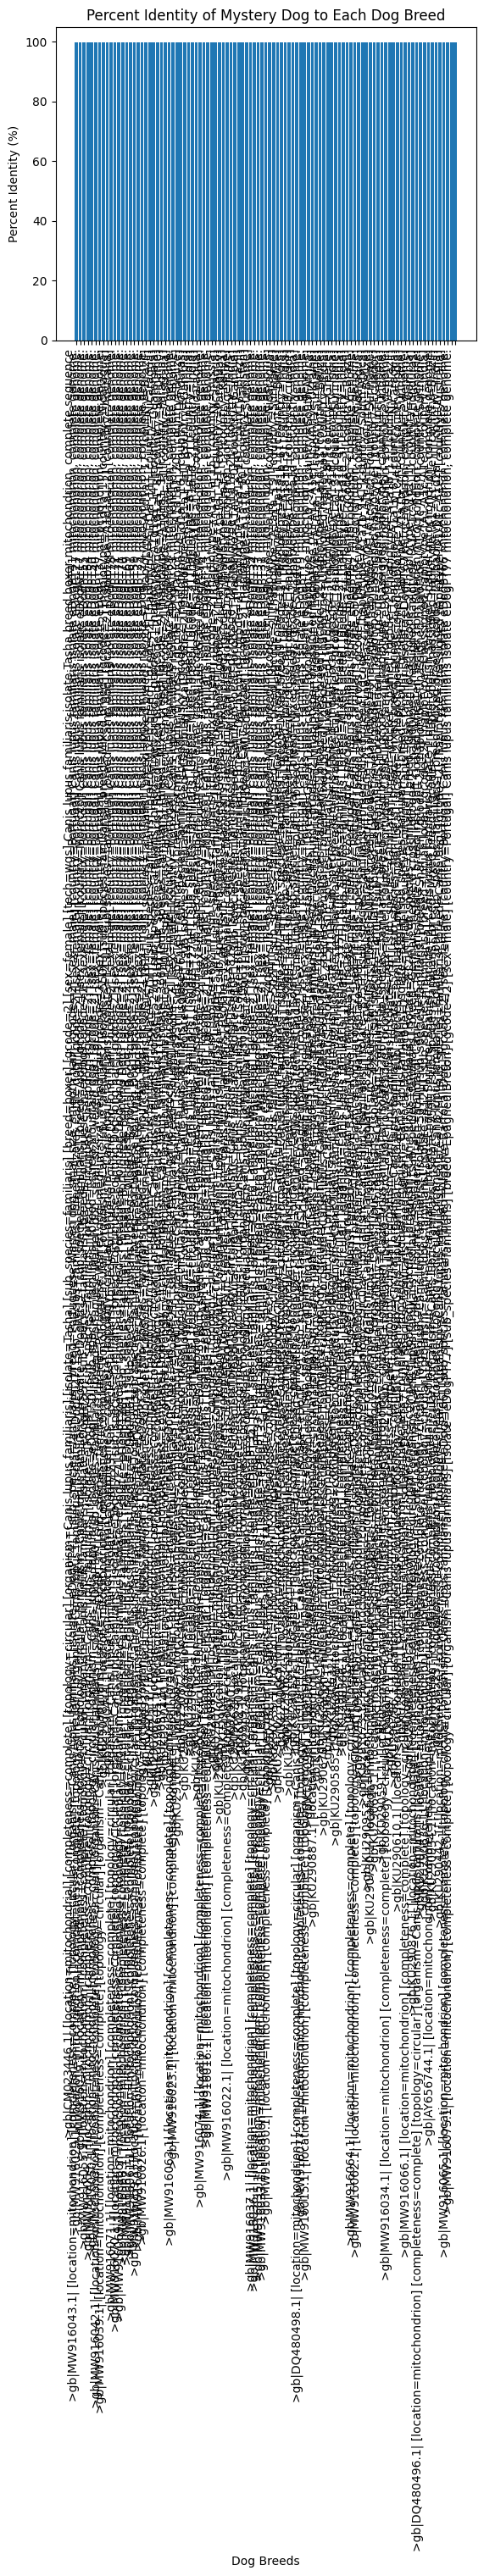

{'>gb|CM023446.1| [location=mitochondrial] [completeness=complete] [topology=circular] [organism=Canis lupus familiaris] [isolate=Tasha] [sub_species=familiaris] [breed=boxer] [gcode=2] [sex=female] [tech=wgs] Canis lupus familiaris isolate Tasha breed boxer mitochondrion, complete sequence\n': 99.7609799820735,
 '>gb|MW916043.1| [location=mitochondrion] [completeness=complete] [topology=circular] [organism=Canis lupus familiaris] [isolate=eDogPT41] [sub_species=familiaris] [breed=Portuguese Warren dog, small size, smooth hair] [gcode=2] [sex=male] [country=Portugal] Canis lupus familiaris isolate eDogPT41 mitochondrion, complete genome.\n': 99.71915147893637,
 '>gb|MW916029.1| [location=mitochondrion] [completeness=complete] [topology=circular] [organism=Canis lupus familiaris] [isolate=eDogPT27] [sub_species=familiaris] [breed=Azores Cattle dog] [gcode=2] [sex=female] [country=Portugal] Canis lupus familiaris isolate eDogPT27 mitochondrion, complete genome.\n': 99.7131759784882,
 '>g

In [ ]:
# Had to add full pathway for VSC to be able to read and open the file.
def dictionary_dogs(dog_breed_database='C:\\Users\\15bcl\\Documents\\Bioinformatics\\Biocomputing\\Project Files\\project_dog_dna\\project_dog_dna\\dog_breeds.fa',mystery_dog_sequence='C:\\Users\\15bcl\\Documents\\Bioinformatics\\Biocomputing\\Project Files\\project_dog_dna\\project_dog_dna\\mystery.fa'):
# Defines variable as an empty dictionary to store the dog breed information from the database.
    dog_dictionary = {}
# Opens the dog breed database file. 
    with open(dog_breed_database, 'r') as f_dog_database: 
# Defines variable as an empty string to add into dictionary later.
        dog_str=''
# Defines variable as an empty string to add into dictionary later.
        dog_dna=''
# Loops over file one line at a time until the nd of the file.   
        for line in f_dog_database:
# If the line starts with '>', it indicates the start of a new dog breed. 
            if line.startswith('>'):
# Storing the current dog breed information to be used in the dictionary later.
                dog_str=line
# Everytime a new dog breed in found, the DNA variable is reset to an empty string.
                dog_dna=''
# Adding a new empty entry called dog_str to the dictionary.
                dog_dictionary[dog_str]=dog_dna
            else:
# If the line does not start with '>', it is part of the DNA sequence for the current dog breed. 
                dog_dna+=line.strip()
# After processing the line, the DNA sequence is updated in the dictionary for the current dog breed.
                dog_dictionary[dog_str]=dog_dna

# Opens the mystery dog sequence file.
    with open(mystery_dog_sequence, 'r') as f_mystery_dog:
# Defines variable as an empty string to have the mystery dog DNA sequence stored in it.
        mystery_str=''
# Loops over file one line at a time until the end of the file.
        for line in f_mystery_dog:
# Ignoring the first line of the mystery sequence as it isn't part of the DNA sequence needed to be compared.
            if line.startswith('>')==False: 
# Adding the next line of the sequence to the string and removing unneceassy characters. 
                mystery_str+=line.strip()

    return mystery_str, dog_dictionary





def compare_sequences(mystery_sequence_for_comparison, dog_dictionary_for_comparison):
# Defines variable as an empty dictionary to store the percent identity values for each dog breed.
    percent_identity_dictionary = {}
# Loops through the dictionary until the end of the dictionary is reached.
    for dog_breed in dog_dictionary_for_comparison:  
# Defines variable as an empty string to store the DNA sequence for the current dog breed being compared.
        dog_breed_dna = dog_dictionary_for_comparison[dog_breed]  
# Defines variable as an integer to count the number of matching characters between the mystery sequence and the current dog breed sequence.
        match_count = 0
# Loops through the DNA sequence of the current dog breed and compares it to the mystery sequence one character at a time.
        for i in range(min(len(mystery_sequence_for_comparison), len(dog_breed_dna))):
# If the characters at the current position in both sequences match, the match count is incremented by 1.
            if mystery_sequence_for_comparison[i] == dog_breed_dna[i]: 
                match_count += 1
# After comparing the sequences, the percent identity is calculated by dividing the match count by the length of the shorter sequence and multiplying by 100 to get a percentage.
        percent_identity = (match_count / min(len(mystery_sequence_for_comparison), len(dog_breed_dna))) * 100
# The percent identity value is stored in the percent identity dictionary with the dog breed as the key and the percent identity as the value.
        percent_identity_dictionary[dog_breed] = percent_identity
# After all dog breeds have been compared, the percent identity dictionary is returned.
    
    return percent_identity_dictionary


dog_results = dictionary_dogs()
compare_sequences(dog_results[0], dog_results[1])

# This function stops the other functions from outputting the dictionary which is wrong. It needs to output the dictionary too...
# ... so need to find a fix for this. 
def highest_percent_identity(percent_identity_dictionary_for_comparison):
# Defines variable as an empty string to store the dog breed with the highest percent identity.
    highest_percent_identity_dog = ''   
# Defines variable as a float to store the highest percent identity value found during the comparison.
    highest_percent_identity_value = 0.0
# Loops through the percent identity dictionary until the end of the dictionary is reached.
    for dog_breed in percent_identity_dictionary_for_comparison:
# If the percent identity value for the current dog breed is higher than the highest percent identity value found so far, the highest percent identity value and the corresponding dog breed are updated.
        if percent_identity_dictionary_for_comparison[dog_breed] > highest_percent_identity_value:
            highest_percent_identity_value = percent_identity_dictionary_for_comparison[dog_breed]
            highest_percent_identity_dog = dog_breed
# After looping through all the dog breeds, the dog breed with the highest percent identity and its corresponding percent identity value are returned as a tuple.       
        return highest_percent_identity_dog, highest_percent_identity_value
    
    
percent_identity_results = compare_sequences(dog_results[0], dog_results[1])
highest_percent_identity(percent_identity_results)




# The plot is really messy and hard to read...
# ... need to come back to this to fix it. 
# Also need to output it in the file results_folder.

import matplotlib.pyplot as plt

def plot_percent_identity(percent_identity_dictionary_for_plotting):
# Defines variable as an empty list to store the dog breeds for the x-axis of the plot.
    dog_breeds = []
# Defines variable as an empty list to store the percent identity values for the y-axis of the plot.
    percent_identity_values = []
# Loops through the percent identity dictionary until the end of the dictionary is reached.
    for dog_breed in percent_identity_dictionary_for_plotting:
# Appends the current dog breed to the dog breeds list and its corresponding percent identity value to the percent identity values list.
        dog_breeds.append(dog_breed)
        percent_identity_values.append(percent_identity_dictionary_for_plotting[dog_breed]) 
# Creates a bar plot using the dog breeds as the x-axis and the percent identity values as the y-axis.
    plt.bar(dog_breeds, percent_identity_values)
# Sets the title and labels for the plot.
    plt.title('Percent Identity of Mystery Dog to Each Dog Breed')
    plt.xlabel('Dog Breeds')
    plt.ylabel('Percent Identity (%)')
# Rotates the x-axis labels for better readability.
    plt.xticks(rotation=90)
# Displays the plot.
    plt.show()

    return percent_identity_dictionary_for_plotting

plot_percent_identity(percent_identity_results)